# Prediction of Diabetes Using Machine Learning

In [1]:
import pandas as pd
import numpy as np
import os, time, math
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.pipeline import Pipeline as ImbPipeline

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import *
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import *
from sklearn.ensemble import *
import xgboost
from xgboost import XGBClassifier
import lightgbm
from lightgbm import LGBMClassifier

import warnings
warnings.filterwarnings('ignore')

## Loading Dataset

In [2]:
import kagglehub

# dwnloading latest version
path = kagglehub.dataset_download("alexteboul/diabetes-health-indicators-dataset")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/diabetes-health-indicators-dataset


In [3]:
os.listdir(path)

['diabetes_binary_5050split_health_indicators_BRFSS2015.csv',
 'diabetes_binary_health_indicators_BRFSS2015.csv',
 'diabetes_012_health_indicators_BRFSS2015.csv']

In [4]:
df = pd.read_csv(path + "/diabetes_012_health_indicators_BRFSS2015.csv")

data = df.copy()
data.head()

,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


## EDA
Perform exploratory data analysis (EDA) on the dataset.

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Diabetes_012          253680 non-null  float64
 1   HighBP                253680 non-null  float64
 2   HighChol              253680 non-null  float64
 3   CholCheck             253680 non-null  float64
 4   BMI                   253680 non-null  float64
 5   Smoker                253680 non-null  float64
 6   Stroke                253680 non-null  float64
 7   HeartDiseaseorAttack  253680 non-null  float64
 8   PhysActivity          253680 non-null  float64
 9   Fruits                253680 non-null  float64
 10  Veggies               253680 non-null  float64
 11  HvyAlcoholConsump     253680 non-null  float64
 12  AnyHealthcare         253680 non-null  float64
 13  NoDocbcCost           253680 non-null  float64
 14  GenHlth               253680 non-null  float64
 15  

In [6]:
display(data.describe())

,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
count,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,...,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000
mean,0.296921,0.429001,0.424121,0.962670,28.382364,0.443169,0.040571,0.094186,0.756544,0.634256,...,0.951053,0.084177,2.511392,3.184772,4.242081,0.168224,0.440342,8.032119,5.050434,6.053875
std,0.698160,0.494934,0.494210,0.189571,6.608694,0.496761,0.197294,0.292087,0.429169,0.481639,...,0.215759,0.277654,1.068477,7.412847,8.717951,0.374066,0.496429,3.054220,0.985774,2.071148
min,0.000000,0.000000,0.000000,0.000000,12.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,1.000000,24.000000,0.000000,0.000000,0.000000,1.000000,0.000000,...,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,6.000000,4.000000,5.000000
50%,0.000000,0.000000,0.000000,1.000000,27.000000,0.000000,0.000000,0.000000,1.000000,1.000000,...,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,8.000000,5.000000,7.000000
75%,0.000000,1.000000,1.000000,1.000000,31.000000,1.000000,0.000000,0.000000,1.000000,1.000000,...,1.000000,0.000000,3.000000,2.000000,3.000000,0.000000,1.000000,10.000000,6.000000,8.000000
max,2.000000,1.000000,1.000000,1.000000,98.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,5.000000,30.000000,30.000000,1.000000,1.000000,13.000000,6.000000,8.000000


### Univariate Analysis
- Analysing the distribution of individual features by calculating value counts for categorical/binary columns and descriptive statistics for numerical/ordinal columns, and also examine the distribution of the target variable.



In [7]:
# print the list of columns to identify the correct name
print(data.columns)

Index(['Diabetes_012', 'HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker',
       'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies',
       'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth',
       'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education',
       'Income'],
      dtype='object')


In [8]:
# identifying categorical/binary and numerical/ordinal columns based on the instructions
# correcting the column name based on the actual dataframe columns
categorical_cols = ['HighBP', 'HighChol', 'Stroke', 'HeartDiseaseorAttack', 'CholCheck', 'Smoker',
                    'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'Sex', 'DiffWalk', 'PhysActivity'] # Corrected typo and added 'DiffWalk', 'PhysActivity' as they seem binary
numerical_cols = ['BMI', 'GenHlth', 'MentHlth', 'PhysHlth', 'Age', 'Education', 'Income']

In [9]:
# analysing categorical/binary columns
print("Value Counts for Categorical/Binary Columns:")
for col in categorical_cols:
    print(f"\n--- {col} ---")
    display(data[col].value_counts())

Value Counts for Categorical/Binary Columns:

--- HighBP ---


,count
HighBP,
0.0,144851
1.0,108829



--- HighChol ---


,count
HighChol,
0.0,146089
1.0,107591



--- Stroke ---


...

,count
Sex,
0.0,141974
1.0,111706



--- DiffWalk ---


,count
DiffWalk,
0.0,211005
1.0,42675



--- PhysActivity ---


,count
PhysActivity,
1.0,191920
0.0,61760


In [10]:
# analysing numerical/ordinal columns
print("\nDescriptive Statistics for Numerical/Ordinal Columns:")
display(data[numerical_cols].describe())

# analysing the target variable 'Diabetes_012'
print("\nValue Counts for Target Variable 'Diabetes_012':")
display(data['Diabetes_012'].value_counts())


Descriptive Statistics for Numerical/Ordinal Columns:


,BMI,GenHlth,MentHlth,PhysHlth,Age,Education,Income
count,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000
mean,28.382364,2.511392,3.184772,4.242081,8.032119,5.050434,6.053875
std,6.608694,1.068477,7.412847,8.717951,3.054220,0.985774,2.071148
min,12.000000,1.000000,0.000000,0.000000,1.000000,1.000000,1.000000
25%,24.000000,2.000000,0.000000,0.000000,6.000000,4.000000,5.000000
50%,27.000000,2.000000,0.000000,0.000000,8.000000,5.000000,7.000000
75%,31.000000,3.000000,2.000000,3.000000,10.000000,6.000000,8.000000
max,98.000000,5.000000,30.000000,30.000000,13.000000,6.000000,8.000000



Value Counts for Target Variable 'Diabetes_012':


,count
Diabetes_012,
0.0,213703
2.0,35346
1.0,4631


### Bivariate Analysis
- Exploring the relationships between pairs of variables,particularly between the target variable ('Diabetes_012') and other features, to identify potential predictors.


In [11]:
# select a few key features based on potential relevance and previous analysis
selected_categorical_features = ['HighBP', 'HighChol', 'Stroke', 'HeartDiseaseorAttack', 'Sex']
selected_numerical_features = ['BMI', 'Age', 'GenHlth', 'Income']

# explore relationships for categorical features using grouping and aggregation
print("Relationship between Categorical Features and Diabetes_012:")
for col in selected_categorical_features:
    print(f"\n--- {col} vs Diabetes_012 ---")
    display(data.groupby(col)['Diabetes_012'].value_counts(normalize=True).unstack().fillna(0))

Relationship between Categorical Features and Diabetes_012:

--- HighBP vs Diabetes_012 ---


Diabetes_012,0.0,1.0,2.0
HighBP,,,
0.0,0.927788,0.011860,0.060352
1.0,0.728776,0.026767,0.244457



--- HighChol vs Diabetes_012 ---


Diabetes_012,0.0,1.0,2.0
HighChol,,,
0.0,0.908166,0.012020,0.079814
1.0,0.753130,0.026722,0.220149



--- Stroke vs Diabetes_012 ---


Diabetes_012,0.0,1.0,2.0
Stroke,,,
0.0,0.850264,0.017938,0.131798
1.0,0.656724,0.025748,0.317528



--- HeartDiseaseorAttack vs Diabetes_012 ---


Diabetes_012,0.0,1.0,2.0
HeartDiseaseorAttack,,,
0.0,0.863199,0.017264,0.119537
1.0,0.642489,0.027791,0.329720



--- Sex vs Diabetes_012 ---


Diabetes_012,0.0,1.0,2.0
Sex,,,
0.0,0.851980,0.018341,0.129679
1.0,0.830251,0.018146,0.151603



Relationship between Numerical Features and Diabetes_012:


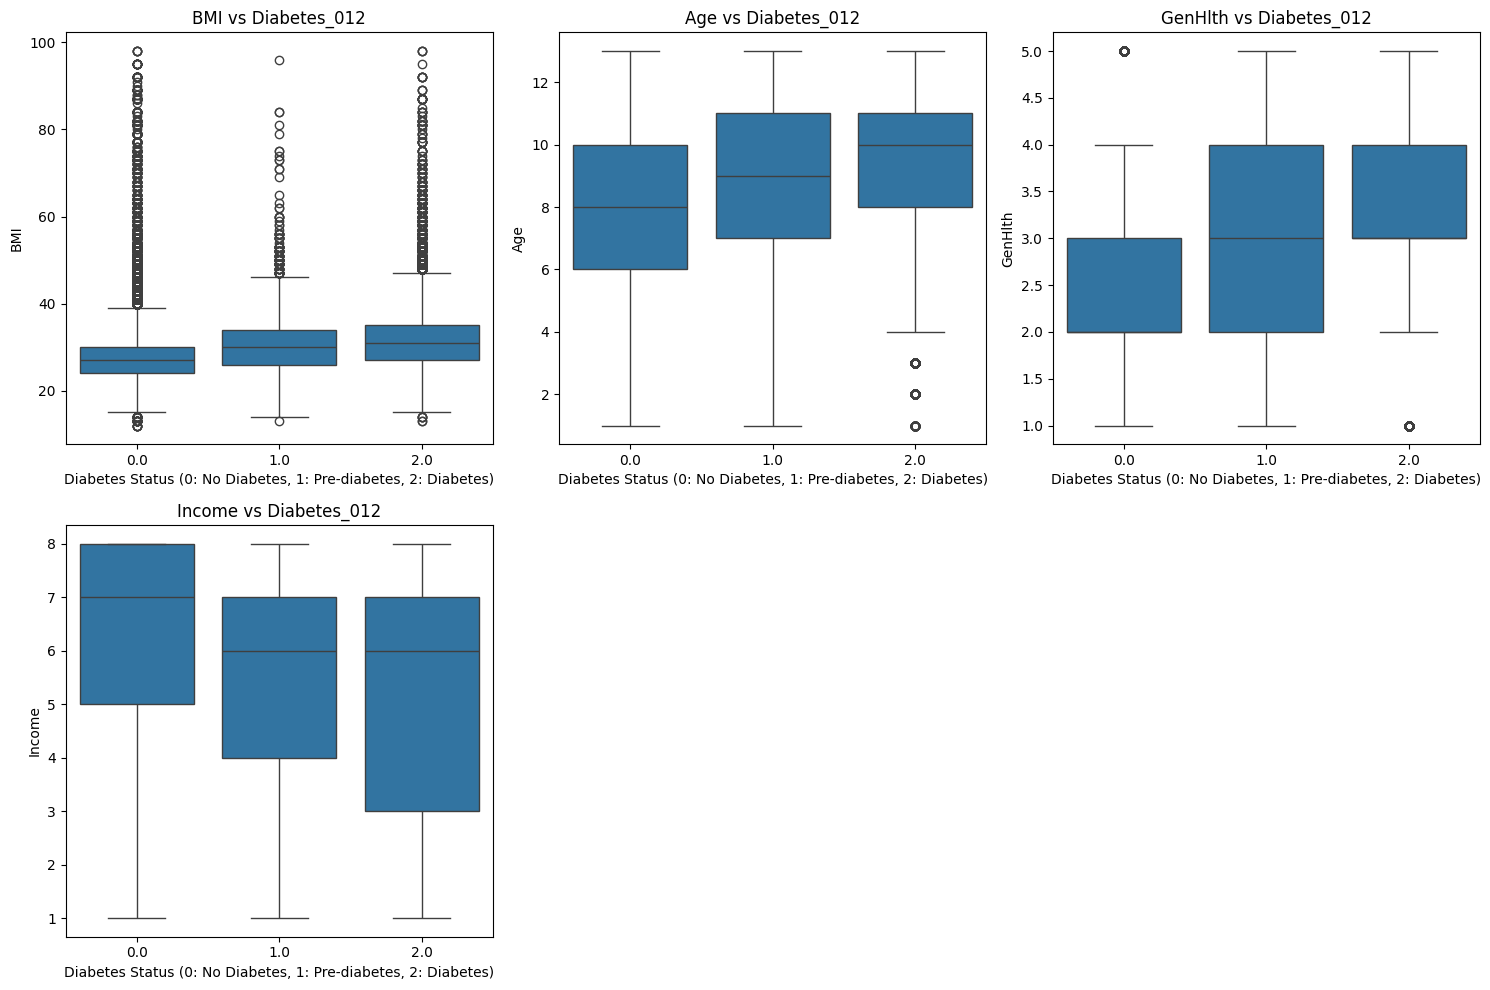

In [12]:
import math

# explore relationships for numerical features using subplots
print("\nRelationship between Numerical Features and Diabetes_012:")

num_features = len(selected_numerical_features)

# decide grid size (e.g., 3 columns)
cols = 3
rows = math.ceil(num_features / cols)

fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 5 * rows))
axes = axes.flatten()

for i, col in enumerate(selected_numerical_features):
    sns.boxplot(x='Diabetes_012', y=col, data=data, ax=axes[i])
    axes[i].set_title(f'{col} vs Diabetes_012')
    axes[i].set_xlabel('Diabetes Status (0: No Diabetes, 1: Pre-diabetes, 2: Diabetes)')
    axes[i].set_ylabel(col)

# remove empty subplots if any
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

## Analysing Class Imbalance
- Checking for class imbalance in the target variable and consider techniques like oversampling or undersampling if necessary.
- This section will include multiple plots, such as
  - Bar Chart of Target Variable
  - Pie Chart of Target Variable


In [13]:
# calculating and print the value counts for the 'Diabetes_012' column
print("Value counts for 'Diabetes_012' column:")
display(data['Diabetes_012'].value_counts())

# calculating and print the normalized value counts (percentages)
print("\nNormalized value counts for 'Diabetes_012' column (percentages):")
display(data['Diabetes_012'].value_counts(normalize=True) * 100)

Value counts for 'Diabetes_012' column:


,count
Diabetes_012,
0.0,213703
2.0,35346
1.0,4631



Normalized value counts for 'Diabetes_012' column (percentages):


,proportion
Diabetes_012,
0.0,84.241170
2.0,13.933302
1.0,1.825528


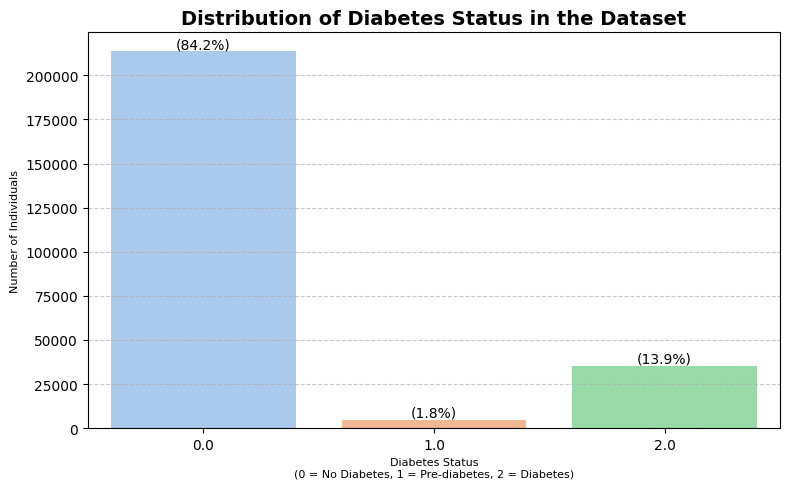

In [14]:
# create an annotated bar plot of the target variable 'Diabetes_012'
plt.figure(figsize=(8, 5))
ax = sns.countplot(x='Diabetes_012', data=data, palette="pastel")

# annotate bars with counts and percentages
total = len(data)
for p in ax.patches:
    count = int(p.get_height())
    percentage = 100 * count / total
    ax.annotate(f'({percentage:.1f}%)',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=10, color='black')

# Improve readability with titles and axis labels
plt.title('Distribution of Diabetes Status in the Dataset', fontsize=14, fontweight='bold')
plt.xlabel('Diabetes Status\n(0 = No Diabetes, 1 = Pre-diabetes, 2 = Diabetes)', fontsize=8)
plt.ylabel('Number of Individuals', fontsize=8)

# Add gridlines for readability
plt.grid(axis='y',
         linestyle='--',
         alpha=0.7)

plt.tight_layout()
plt.show()

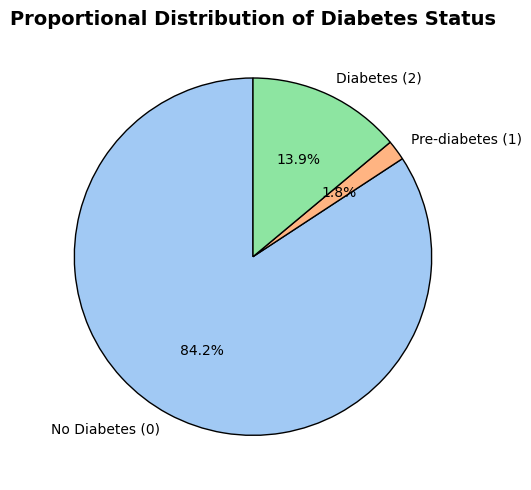

In [15]:
# --- Pie Chart for Proportions ---
diabetes_counts = data['Diabetes_012'].value_counts().sort_index()
labels = ['No Diabetes (0)', 'Pre-diabetes (1)', 'Diabetes (2)']
colors = sns.color_palette("pastel")[0:3]

plt.figure(figsize=(10, 5))
plt.pie(diabetes_counts,
        labels=labels,
        autopct='%1.1f%%',
        startangle=90,
        colors=colors,
        wedgeprops={'edgecolor': 'black'})

plt.title('Proportional Distribution of Diabetes Status',
          fontsize=14,
          fontweight='bold')
plt.tight_layout()
plt.show()

### Correlation analysis
Calculating and visualize the correlation matrix to understand the linear relationships between numerical variables.


Most Strongly Correlated Features with Diabetes_012:


,Diabetes_012
GenHlth,0.302587
HighBP,0.271596
BMI,0.224379
DiffWalk,0.224239
HighChol,0.209085
Age,0.185026
HeartDiseaseorAttack,0.180272
PhysHlth,0.176287
Stroke,0.107179
MentHlth,0.073507


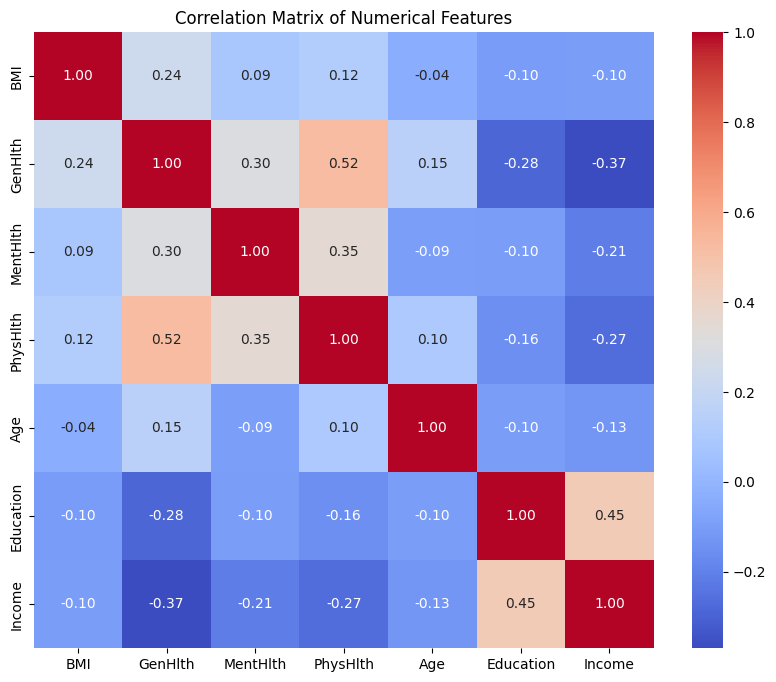

In [16]:
# select only the numerical columns. The list 'numerical_cols' was defined in a previous step.
numerical_data = data[numerical_cols]

# calculate the correlation matrix
correlation_matrix = numerical_data.corr()

# calculate correlation with the target variable
# Assuming the target variable 'Diabetes_012' is in the original 'data' DataFrame
correlation_with_target = data.corr()['Diabetes_012'].sort_values(ascending=False)

# Exclude the target variable itself from the list
correlation_with_target = correlation_with_target.drop('Diabetes_012', errors='ignore')

# Display the most strongly correlated features
print("Most Strongly Correlated Features with Diabetes_012:")
display(correlation_with_target)

# create a heatmap of the correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numerical Features')
plt.show()

Box plots to visualize outliers in numerical columns:


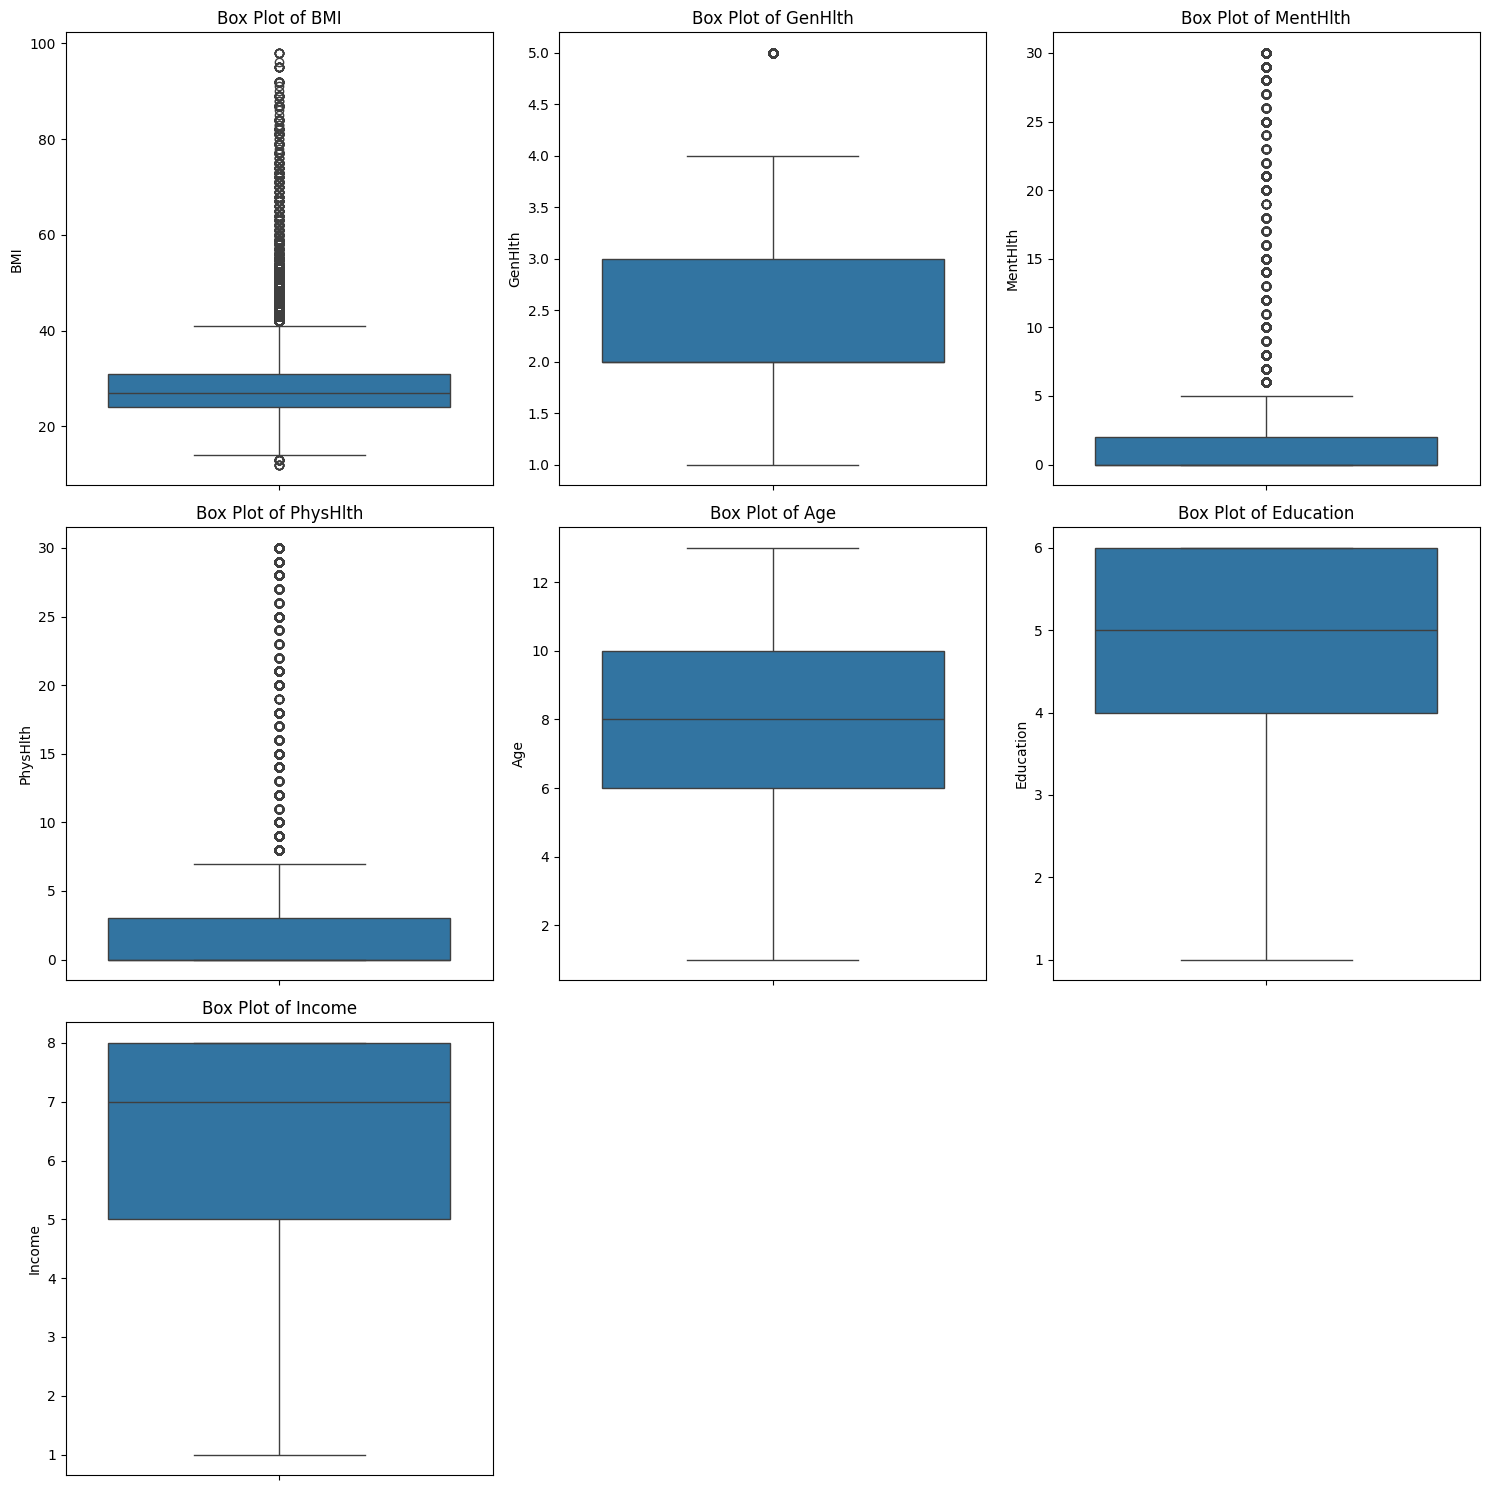


Number of outliers in each numerical column (using IQR):
BMI: 9847 outliers
GenHlth: 12081 outliers
MentHlth: 36208 outliers
PhysHlth: 40949 outliers
Age: 0 outliers
Education: 0 outliers
Income: 0 outliers


In [17]:
# function to detect outliers using IQR
def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return outliers

# visualising outliers using box plots for numerical columns
print("Box plots to visualize outliers in numerical columns:")
num_features = len(numerical_cols)
cols = 3
rows = math.ceil(num_features / cols)

fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 5 * rows))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    sns.boxplot(y=data[col], ax=axes[i])
    axes[i].set_title(f'Box Plot of {col}')
    axes[i].set_ylabel(col)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

# printing the number of outliers for each numerical column
print("\nNumber of outliers in each numerical column (using IQR):")
for col in numerical_cols:
    outliers = detect_outliers_iqr(data, col)
    print(f"{col}: {len(outliers)} outliers")

## Summary of Data Analysis
### Data Analysis Key Findings

*   The dataset contains 253,680 records and 22 features with no missing values.
*   The target variable 'Diabetes_012' is significantly imbalanced, with the "No Diabetes" class (0.0) representing about 84.24% of the data, while "Diabetes" (2.0) is around 13.93%, and "Pre-diabetes" (1.0) is only about 1.83%.
*   Individuals with 'HighBP', 'HighChol', a history of 'Stroke', or 'HeartDiseaseorAttack' have a substantially higher prevalence of diabetes.
*   Higher 'BMI' and 'Age' are associated with an increased likelihood of pre-diabetes and diabetes.
*   Individuals reporting poorer 'GenHlth' (General Health) are more likely to be in the pre-diabetes or diabetes categories.
*   Lower 'Income' levels appear to be associated with a higher prevalence of diabetes.
*   Among numerical features, 'GenHlth' shows moderate positive correlations with 'MentHlth' and 'PhysHlth', while 'Income' and 'Education' have a moderate positive correlation. 'GenHlth', 'MentHlth', and 'PhysHlth' show moderate negative correlations with 'Income' and 'Education'.

### Insights from Analysis

*   The significant class imbalance in the target variable needs to be addressed using techniques like oversampling or undersampling before training a predictive model to ensure fair and accurate performance across all classes.
*   The features identified as strong potential predictors ('HighBP', 'HighChol', 'Stroke', 'HeartDiseaseorAttack', 'BMI', 'Age', 'GenHlth', 'Income') should be prioritized in subsequent feature selection and model building steps for predicting diabetes.


## Data Preprocessing Pipeline

In [18]:
# --- Feature definitions ---
categorical_features = ['HighBP', 'HighChol', 'Stroke', 'HeartDiseaseorAttack', 'CholCheck',
                        'Smoker', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare',
                        'NoDocbcCost', 'Sex', 'DiffWalk', 'PhysActivity']

numerical_features = ['BMI', 'GenHlth', 'MentHlth', 'PhysHlth', 'Age', 'Education', 'Income']
target = 'Diabetes_012'

# --- Map target ---
target_map = {0:0, 1:1, 2:1}
data[target] = data['Diabetes_012'].map(target_map)

X = data.drop(target, axis=1)
y = data[target]

# ---- Dataset Splitting ------

X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.2,
                                                    random_state=42, stratify=y)

# --- Preprocessing ---
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# --- Final pipeline ---
model_rf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42))
])

print("Data preprocessing pipeline created successfully.")

Data preprocessing pipeline created successfully.


In [19]:
X_train.shape, y_train.shape

((202944, 21), (202944,))

In [20]:
y_train.value_counts()

,count
Diabetes_012,
0,170962
1,31982


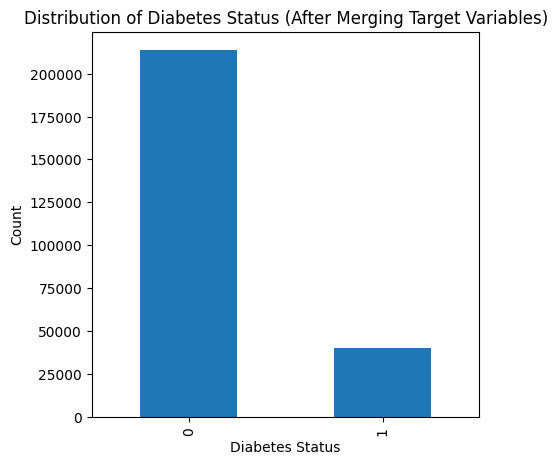

In [21]:
plt.figure(figsize=(5, 5))
y.value_counts().plot(kind='bar')
plt.title('Distribution of Diabetes Status (After Merging Target Variables)')
plt.xlabel('Diabetes Status')
plt.ylabel('Count')
plt.show()

## General Function for Results
### Function `evaluate_classifier ()`
    """
    Evaluates a classifier and prints key metrics.

    Args:
        classifier: The trained classifier model.
        X_train: Training features.
        X_test: Testing features.
        y_train: Training labels.
        y_test: Testing labels.
        classifier_name: Name of the classifier.
    """

In [22]:
def evaluate_classifier(classifier, X_train, X_test, y_train, y_test, classifier_name):
    print(f"--- Evaluating {classifier_name} ---")

    # predictions
    y_pred = classifier.predict(X_test)
    y_pred_proba = classifier.predict_proba(X_test)[:, 1]

    # accuracy
    accuracy = accuracy_score(y_test, y_pred)
    print("Accuracy: %.2f%%" % (accuracy * 100))

    # classification Report
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    # prepare confusion matrix
    cm = confusion_matrix(y_test, y_pred)

    # Prepare ROC-AUC values
    fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
    roc_auc = auc(fpr, tpr)

    # create a single-row figure with two subplots
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # --- Confusion Matrix ---
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[0])
    axes[0].set_title(f'Confusion Matrix\n({classifier_name})', fontsize=12)
    axes[0].set_xlabel('Predicted')
    axes[0].set_ylabel('Actual')

    # --- ROC Curve ---
    axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {roc_auc:.2f}')
    axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    axes[1].set_xlim([0.0, 1.0])
    axes[1].set_ylim([0.0, 1.05])
    axes[1].set_xlabel('False Positive Rate')
    axes[1].set_ylabel('True Positive Rate')
    axes[1].set_title(f'ROC Curve\n({classifier_name})', fontsize=12)
    axes[1].legend(loc="lower right")

    # Adjust layout and display
    plt.tight_layout()
    plt.show()

    print("-" * (len(classifier_name) + 19))

    return accuracy

## Application of Models (Before Re-Sampling)

### Applying Random Forest

In [23]:
model_rf.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['BMI', 'GenHlth', 'MentHlth',
                                                   'PhysHlth', 'Age',
                                                   'Education', 'Income']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['HighBP', 'HighChol',
                                                   'Stroke',
                                                   'HeartDiseaseorAttack',
                                                   'CholCheck', 'Smoker',
                                                   'Fruits', 'Veggies',
                                                   'HvyAlcoholConsump',
                                                   'AnyHealthcare',
                                                   'NoDocbcCost', 'Sex',
                                                   'DiffWalk',
                                                   'PhysActivity'])])),
                ('classifier', RandomForestClassifier(random_state=42))])

--- Evaluating Random Forest ---
Accuracy: 84.29%

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.96      0.91     42741
           1       0.50      0.22      0.30      7995

    accuracy                           0.84     50736
   macro avg       0.69      0.59      0.61     50736
weighted avg       0.81      0.84      0.82     50736



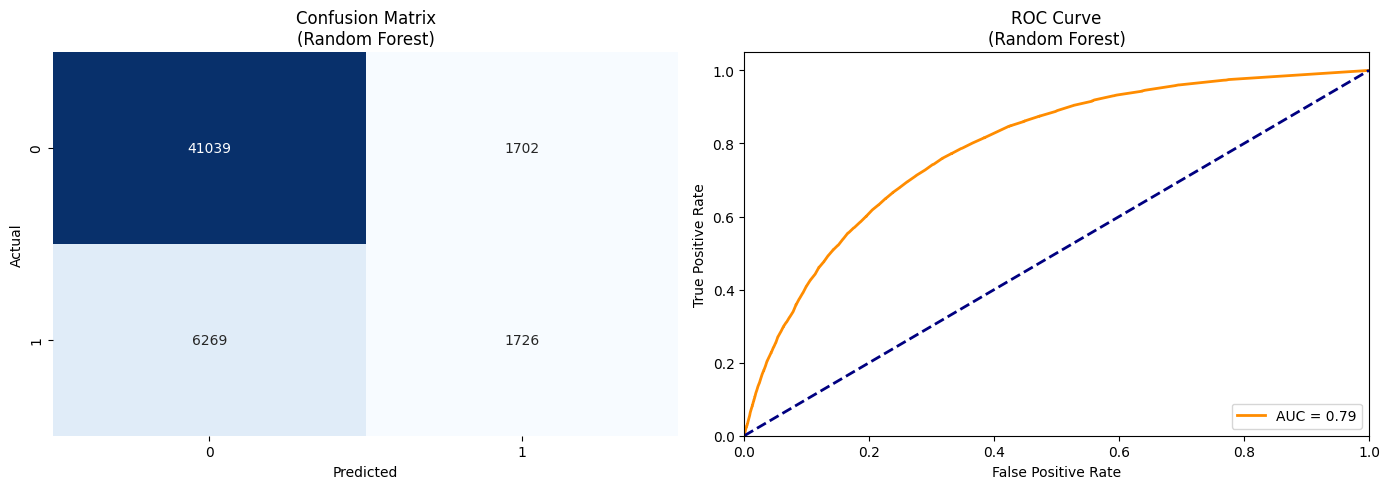

--------------------------------


In [24]:
acc_rf = evaluate_classifier(model_rf, X_train, X_test,
                    y_train, y_test,
                    "Random Forest")

### XGBoost Classifier

In [25]:
model_xgb = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(random_state=42))
])

model_xgb.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['BMI', 'GenHlth', 'MentHlth',
                                                   'PhysHlth', 'Age',
                                                   'Education', 'Income']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignor...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=None,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=None, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=None, n_jobs=None,
                               num_parallel_tree=None, ...))])

--- Evaluating XGBoost ---
Accuracy: 85.05%

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.97      0.92     42741
           1       0.57      0.21      0.30      7995

    accuracy                           0.85     50736
   macro avg       0.72      0.59      0.61     50736
weighted avg       0.82      0.85      0.82     50736



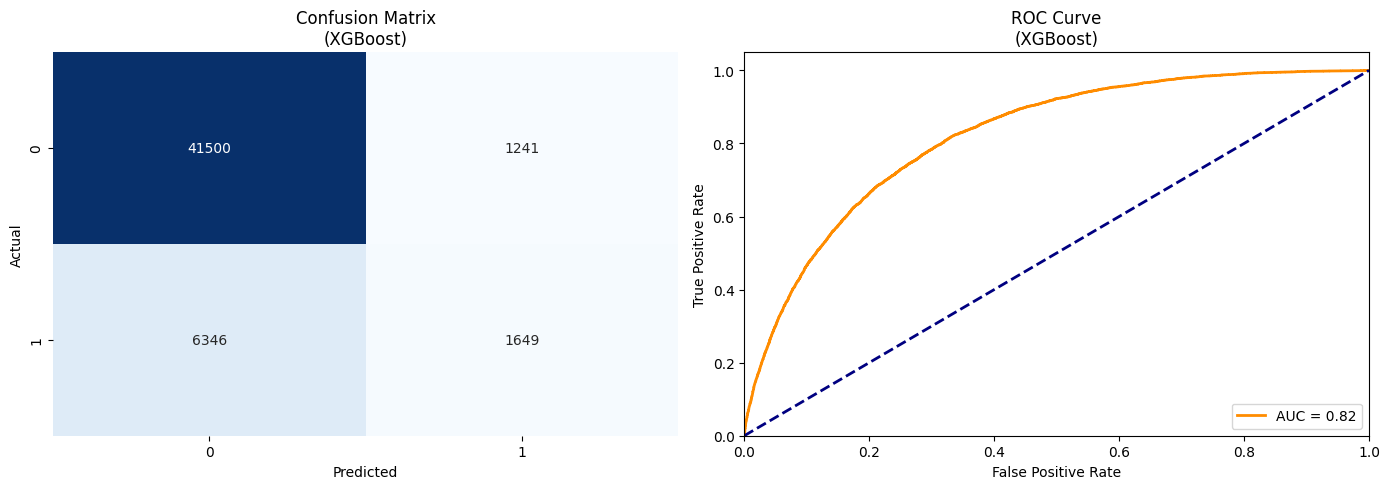

--------------------------


In [26]:
acc_xgb = evaluate_classifier(model_xgb, X_train, X_test,
                    y_train, y_test,
                    "XGBoost")

### Light GBM Classifier

In [27]:
acc_lgbm = model_lgbm = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LGBMClassifier(random_state=42))
])

model_lgbm.fit(X_train, y_train)

[LightGBM] [Info] Number of positive: 31982, number of negative: 170962
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.068133 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 231
[LightGBM] [Info] Number of data points in the train set: 202944, number of used features: 35
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.157590 -> initscore=-1.676268
[LightGBM] [Info] Start training from score -1.676268


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['BMI', 'GenHlth', 'MentHlth',
                                                   'PhysHlth', 'Age',
                                                   'Education', 'Income']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['HighBP', 'HighChol',
                                                   'Stroke',
                                                   'HeartDiseaseorAttack',
                                                   'CholCheck', 'Smoker',
                                                   'Fruits', 'Veggies',
                                                   'HvyAlcoholConsump',
                                                   'AnyHealthcare',
                                                   'NoDocbcCost', 'Sex',
                                                   'DiffWalk',
                                                   'PhysActivity'])])),
                ('classifier', LGBMClassifier(random_state=42))])

--- Evaluating LightGBM ---
Accuracy: 85.23%

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.97      0.92     42741
           1       0.59      0.21      0.31      7995

    accuracy                           0.85     50736
   macro avg       0.73      0.59      0.61     50736
weighted avg       0.82      0.85      0.82     50736



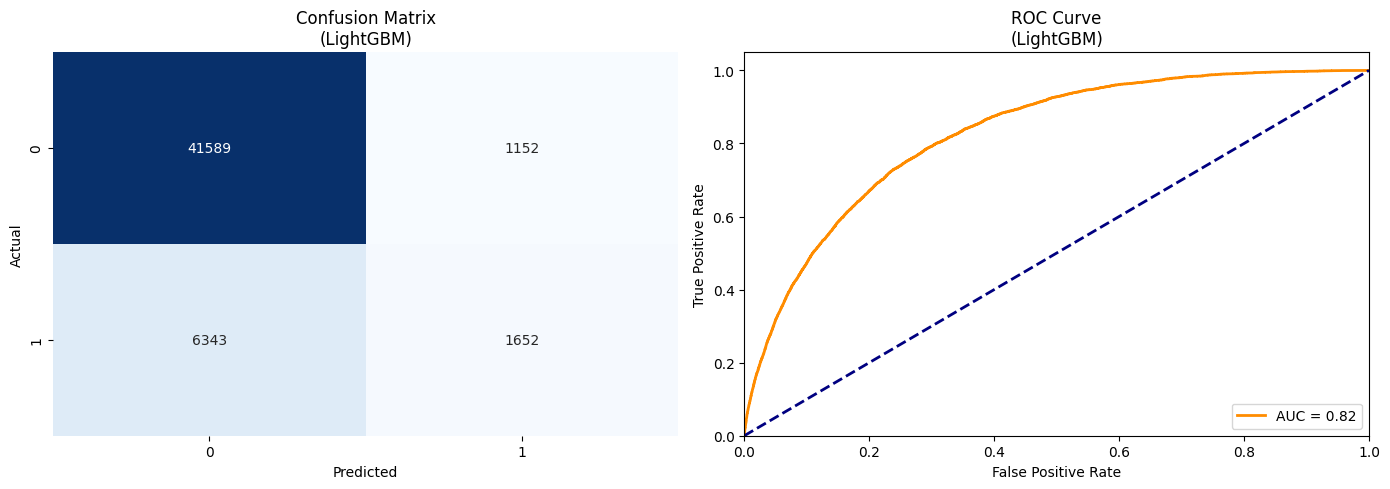

---------------------------


In [28]:
acc_lgbm = evaluate_classifier(model_lgbm, X_train, X_test,
                    y_train, y_test,
                    "LightGBM")

## Applying XAI on Dataset
    """
    Plots the feature importance for a classifier using original feature names.

    Parameters:
    -----------
    X_train, X_test : array-like or DataFrame
        Training and test feature sets.
    y_train, y_test : array-like
        Target variables for train and test.
    feature_names : list, optional
        List of feature names. If None, column names from X_train are used.
    top_n : int, optional
        Number of top features to display. If None, all features are displayed.
    """


### Feature Importance

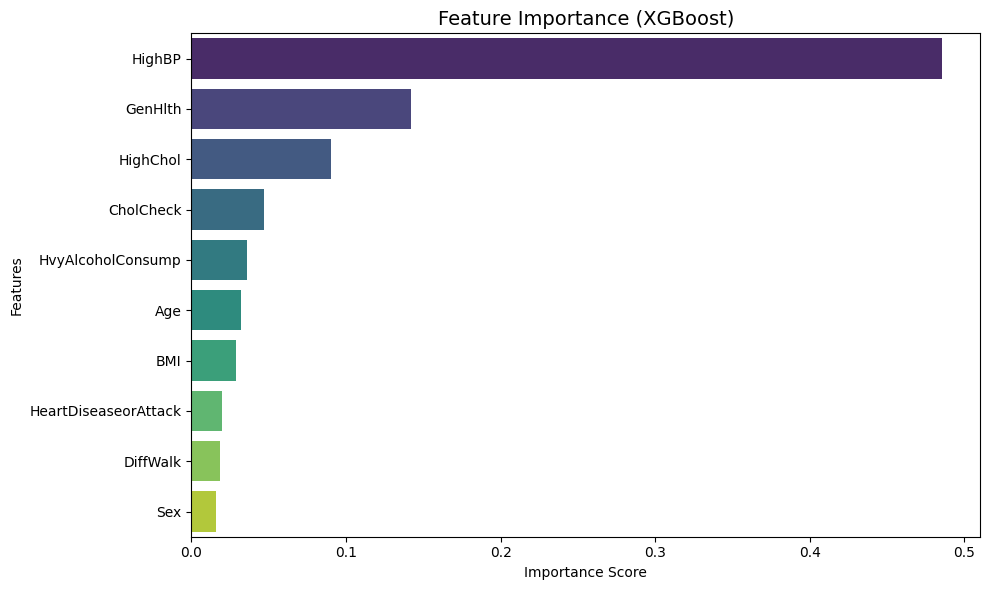

,Feature,Importance
0,HighBP,0.485831
13,GenHlth,0.142237
1,HighChol,0.090172
2,CholCheck,0.046858
10,HvyAlcoholConsump,0.035983
18,Age,0.031927
3,BMI,0.028839
6,HeartDiseaseorAttack,0.019700
16,DiffWalk,0.018496
17,Sex,0.015784


In [30]:
def plot_feature_importance_xgb(X_train, X_test, y_train, y_test, feature_names=None, top_n=None):

    # ensuring DataFrame format for feature names
    if feature_names is None:
        if isinstance(X_train, pd.DataFrame):
            feature_names = X_train.columns
        else:
            feature_names = [f"Feature {i}" for i in range(X_train.shape[1])]

    xgb = XGBClassifier(random_state=42)
    xgb.fit(X_train, y_train)

    # feature importances
    importances = xgb.feature_importances_

    # DataFrame for visualization
    feature_imp_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': importances
    })

    # sort by importance
    feature_imp_df = feature_imp_df.sort_values(by="Importance", ascending=False)

    # select top N features
    if top_n is not None:
        feature_imp_df = feature_imp_df.head(top_n)

    # plot feature importance
    plt.figure(figsize=(10, 6))
    sns.barplot(x="Importance", y="Feature", data=feature_imp_df, palette="viridis")
    plt.title("Feature Importance (XGBoost)", fontsize=14)
    plt.xlabel("Importance Score")
    plt.ylabel("Features")
    plt.tight_layout()
    plt.show()

    return feature_imp_df

plot_feature_importance_xgb(X_train, X_test,
                            y_train, y_test,
                            top_n=10)

### SHAP Visualization

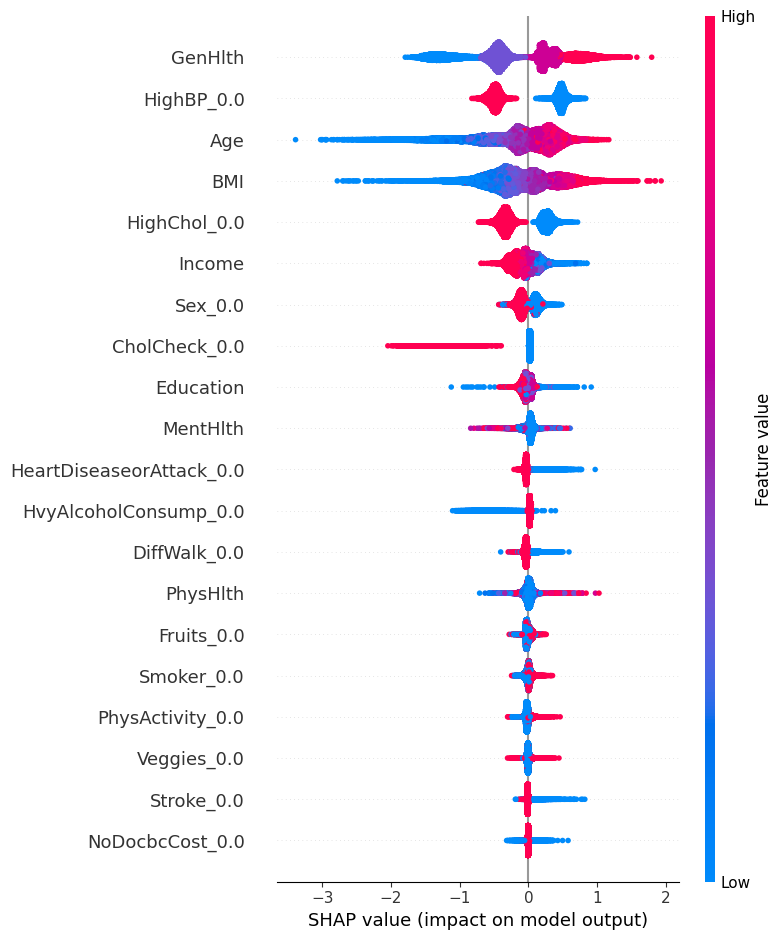

In [32]:
import shap

X_test_processed = model_xgb.named_steps['preprocessor'].transform(X_test)

explainer = shap.TreeExplainer(model_xgb.named_steps['classifier'])

shap_values = explainer.shap_values(X_test_processed)


numerical_features_processed = numerical_features
categorical_features_processed = list(model_xgb.named_steps['preprocessor'].named_transformers_['cat'].named_steps['onehot'].get_feature_names_out(categorical_features))
feature_names_processed = numerical_features_processed + categorical_features_processed

# visualize the SHAP values (e.g., summary plot)
shap.summary_plot(shap_values,
                  X_test_processed,
                  feature_names=feature_names_processed)

## Comparing Accuracies of All

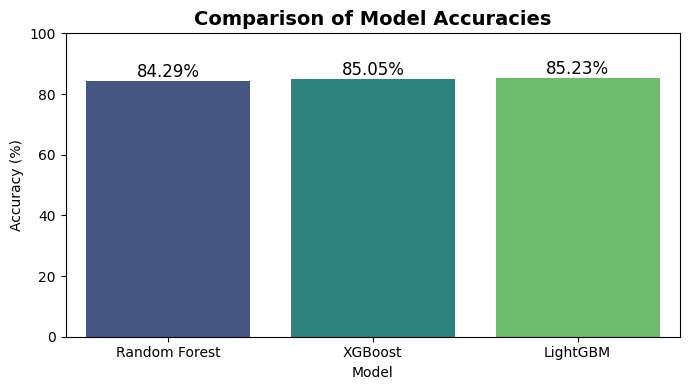

In [34]:
model_names = ['Random Forest', 'XGBoost', 'LightGBM']
accuracies = [acc_rf*100, acc_xgb*100, acc_lgbm*100]

# Create a DataFrame for easy plotting
accuracy_df = pd.DataFrame({'Model': model_names, 'Accuracy': accuracies})

# Create an annotated bar chart
plt.figure(figsize=(7, 4))
ax = sns.barplot(x='Model', y='Accuracy',
                 data=accuracy_df,
                 palette='viridis')

# Annotate the bars with accuracy values
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}%',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=12, color='black')

plt.title('Comparison of Model Accuracies', fontsize=14, fontweight='bold')
plt.xlabel('Model', fontsize=10)
plt.ylabel('Accuracy (%)', fontsize=10)
plt.ylim(0, 100)
plt.tight_layout()
plt.show()